# Task 2

---

## Predictive modeling of customer bookings

This Jupyter notebook includes some code to get you started with this predictive modeling task. We will use various packages for data manipulation, feature engineering and machine learning.

### Exploratory data analysis

First, we must explore the data in order to better understand what we have and the statistical properties of the dataset.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("customer_booking.csv", encoding='latin1')
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


The `.head()` method allows us to view the first 5 rows in the dataset, this is useful for visual inspection of our columns

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  object 
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.3+ 

The `.info()` method gives us a data description, telling us the names of the columns, their data types and how many null values we have. Fortunately, we have no null values. It looks like some of these columns should be converted into different data types, e.g. flight_day.

To provide more context, below is a more detailed data description, explaining exactly what each column means:

- `num_passengers` = number of passengers travelling
- `sales_channel` = sales channel booking was made on
- `trip_type` = trip Type (Round Trip, One Way, Circle Trip)
- `purchase_lead` = number of days between travel date and booking date
- `length_of_stay` = number of days spent at destination
- `flight_hour` = hour of flight departure
- `flight_day` = day of week of flight departure
- `route` = origin -> destination flight route
- `booking_origin` = country from where booking was made
- `wants_extra_baggage` = if the customer wanted extra baggage in the booking
- `wants_preferred_seat` = if the customer wanted a preferred seat in the booking
- `wants_in_flight_meals` = if the customer wanted in-flight meals in the booking
- `flight_duration` = total duration of flight (in hours)
- `booking_complete` = flag indicating if the customer completed the booking

Before we compute any statistics on the data, lets do any necessary data conversion

In [4]:
df["flight_day"].unique()

array(['Sat', 'Wed', 'Thu', 'Mon', 'Sun', 'Tue', 'Fri'], dtype=object)

In [5]:
mapping = {
    "Mon": 1,
    "Tue": 2,
    "Wed": 3,
    "Thu": 4,
    "Fri": 5,
    "Sat": 6,
    "Sun": 7,
}

df["flight_day"] = df["flight_day"].map(mapping)

In [6]:
df["flight_day"].unique()

array([6, 3, 4, 1, 7, 2, 5])

In [7]:
df.describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,flight_day,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,3.814420,0.668780,0.296960,0.427140,7.277561,0.149560
std,1.020165,90.451378,33.88767,5.41266,1.992792,0.470657,0.456923,0.494668,1.496863,0.356643
min,1.000000,0.000000,0.00000,0.00000,1.000000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.00000,5.00000,2.000000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.00000,9.00000,4.000000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.00000,13.00000,5.000000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.00000,23.00000,7.000000,1.000000,1.000000,1.000000,9.500000,1.000000


The `.describe()` method gives us a summary of descriptive statistics over the entire dataset (only works for numeric columns). This gives us a quick overview of a few things such as the mean, min, max and overall distribution of each column.

From this point, you should continue exploring the dataset with some visualisations and other metrics that you think may be useful. Then, you should prepare your dataset for predictive modelling. Finally, you should train your machine learning model, evaluate it with performance metrics and output visualisations for the contributing variables. All of this analysis should be summarised in your single slide.

### Exploratory Data Analysis (EDA)

In [8]:
print(df.info())# gives info about the data types and no records in each column
print(df.shape) # gives the total no of rows and columns
print(df.describe()) # gives statistical info like mean, max,min,std
print(df['booking_complete'].value_counts())# to check the how balance is our target variable


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  int64  
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(9), object(4)
memory usage: 5.3+ 

In [9]:
print(df['booking_complete'].value_counts(normalize=True)*100)
# This gives the Percentage of people who booked the holiday and the who didn't book the holiday.

booking_complete
0    85.044
1    14.956
Name: proportion, dtype: float64


We have a class imbalance here around 85% people didn't book the tickets and only around 15% booked the ticket so to balance I will use
class_weight='balanced' inside RandomForest.

##Feature Engineering  
We are adding new features so that our model can predict better

In [10]:
df['is_weekend'] = df["flight_day"].isin([5,6]).astype(int)
#This feature will tell us if the flightday was a weekend

df['total_add_ons']= df['wants_extra_baggage']+df['wants_in_flight_meals']+df['wants_preferred_seat']
#This feature will give us the total of add ons
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete,is_weekend,total_add_ons
0,2,Internet,RoundTrip,262,19,7,6,AKLDEL,New Zealand,1,0,0,5.52,0,1,1
1,1,Internet,RoundTrip,112,20,3,6,AKLDEL,New Zealand,0,0,0,5.52,0,1,0
2,2,Internet,RoundTrip,243,22,17,3,AKLDEL,India,1,1,0,5.52,0,0,2
3,1,Internet,RoundTrip,96,31,4,6,AKLDEL,New Zealand,0,0,1,5.52,0,1,1
4,2,Internet,RoundTrip,68,22,15,3,AKLDEL,India,1,0,1,5.52,0,0,2


##Encoding Categorical columns


In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder() #creating the lable encoder

df['sales_channel_encoded'] = le.fit_transform(df['sales_channel'])
#.fit() → the encoder looks at the column, finds all unique values ('Internet', 'Mobile') and learns the mapping
# .transform() → it applies the mapping and converts the column to numbers
df['trip_type_encoded'] = le.fit_transform(df['trip_type'])


route_freq_map = df['route'].value_counts() / len(df)# Frequency encoding
df['route_freq'] = df['route'].map(route_freq_map)
df.head()
#Notice we reuse the same le object, this is fine because .fit_transform() resets and relearns from scratch on the new column.

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete,is_weekend,total_add_ons,sales_channel_encoded,trip_type_encoded,route_freq
0,2,Internet,RoundTrip,262,19,7,6,AKLDEL,New Zealand,1,0,0,5.52,0,1,1,0,2,0.0004
1,1,Internet,RoundTrip,112,20,3,6,AKLDEL,New Zealand,0,0,0,5.52,0,1,0,0,2,0.0004
2,2,Internet,RoundTrip,243,22,17,3,AKLDEL,India,1,1,0,5.52,0,0,2,0,2,0.0004
3,1,Internet,RoundTrip,96,31,4,6,AKLDEL,New Zealand,0,0,1,5.52,0,1,1,0,2,0.0004
4,2,Internet,RoundTrip,68,22,15,3,AKLDEL,India,1,0,1,5.52,0,0,2,0,2,0.0004


In [12]:
print(df['booking_origin'].unique())

['New Zealand' 'India' 'United Kingdom' 'China' 'South Korea' 'Japan'
 'Malaysia' 'Singapore' 'Switzerland' 'Germany' 'Indonesia'
 'Czech Republic' 'Vietnam' 'Thailand' 'Spain' 'Romania' 'Ireland' 'Italy'
 'Slovakia' 'United Arab Emirates' 'Tonga' 'Réunion' '(not set)'
 'Saudi Arabia' 'Netherlands' 'Qatar' 'Hong Kong' 'Philippines'
 'Sri Lanka' 'France' 'Croatia' 'United States' 'Laos' 'Hungary'
 'Portugal' 'Cyprus' 'Australia' 'Cambodia' 'Poland' 'Belgium' 'Oman'
 'Bangladesh' 'Kazakhstan' 'Brazil' 'Turkey' 'Kenya' 'Taiwan' 'Brunei'
 'Chile' 'Bulgaria' 'Ukraine' 'Denmark' 'Colombia' 'Iran' 'Bahrain'
 'Solomon Islands' 'Slovenia' 'Mauritius' 'Nepal' 'Russia' 'Kuwait'
 'Mexico' 'Sweden' 'Austria' 'Lebanon' 'Jordan' 'Greece' 'Mongolia'
 'Canada' 'Tanzania' 'Peru' 'Timor-Leste' 'Argentina' 'New Caledonia'
 'Macau' 'Myanmar (Burma)' 'Norway' 'Panama' 'Bhutan' 'Norfolk Island'
 'Finland' 'Nicaragua' 'Maldives' 'Egypt' 'Israel' 'Tunisia'
 'South Africa' 'Papua New Guinea' 'Paraguay' 'Estonia

In [13]:
region_map = {"United Kingdom": "Europe", "Germany": "Europe", "Switzerland": "Europe",
    "Czech Republic": "Europe", "Spain": "Europe", "Romania": "Europe",
    "Ireland": "Europe", "Italy": "Europe", "Slovakia": "Europe",
    "Netherlands": "Europe", "France": "Europe", "Croatia": "Europe",
    "Hungary": "Europe", "Portugal": "Europe", "Cyprus": "Europe",
    "Poland": "Europe", "Belgium": "Europe", "Bulgaria": "Europe",
    "Ukraine": "Europe", "Denmark": "Europe", "Slovenia": "Europe",
    "Russia": "Europe", "Sweden": "Europe", "Austria": "Europe",
    "Greece": "Europe", "Norway": "Europe", "Finland": "Europe",
    "Estonia": "Europe", "Malta": "Europe", "Belarus": "Europe",
    "Gibraltar": "Europe", "Czechia": "Europe","Svalbard & Jan Mayen" :"Europe",

    "United Arab Emirates": "Middle East", "Saudi Arabia": "Middle East",
    "Qatar": "Middle East", "Oman": "Middle East", "Bahrain": "Middle East",
    "Kuwait": "Middle East", "L}ebanon": "Middle East", "Jordan": "Middle East",
    "Iraq": "Middle East", "Israel": "Middle East", "Egypt": "Middle East",
    "Lebanon":"Middle East",

    "India": "South Asia", "Sri Lanka": "South Asia", "Bangladesh": "South Asia",
    "Nepal": "South Asia", "Pakistan": "South Asia", "Maldives": "South Asia",
    "Bhutan": "South Asia", "Afghanistan": "South Asia",

    "China": "East Asia", "South Korea": "East Asia", "Japan": "East Asia",
    "Hong Kong": "East Asia", "Taiwan": "East Asia", "Mongolia": "East Asia",
    "Macau": "East Asia",

    "Malaysia": "Southeast Asia", "Singapore": "Southeast Asia",
    "Indonesia": "Southeast Asia", "Vietnam": "Southeast Asia",
    "Thailand": "Southeast Asia", "Philippines": "Southeast Asia",
    "Laos": "Southeast Asia", "Cambodia": "Southeast Asia",
    "Brunei": "Southeast Asia", "Timor-Leste": "Southeast Asia",
    "Myanmar": "Southeast Asia",

    "New Zealand": "Oceania", "Australia": "Oceania", "Tonga": "Oceania",
    "Solomon Islands": "Oceania", "Papua New Guinea": "Oceania",
    "Vanuatu": "Oceania", "Guam": "Oceania","New Caledonia": "Oceania",
    "Norfolk Island": "Oceania",

    "Kenya": "Africa", "Tanzania": "Africa", "Mauritius": "Africa",
    "South Africa": "Africa", "Seychelles": "Africa", "Ghana": "Africa",
    "Algeria": "Africa", "Tunisia": "Africa",

    "United States": "North & Central America", "Canada": "North & Central America",
    "Mexico": "North & Central America", "Panama": "North & Central America",
    "Guatemala": "North & Central America", "Nicaragua": "North & Central America",

    "Brazil": "South America", "Chile": "South America", "Colombia": "South America",
    "Peru": "South America", "Argentina": "South America", "Paraguay": "South America",

    "Kazakhstan": "Central Asia", "Iran": "Central Asia",

    # Unknown
    '(not set)': 'Unknown', 'Réunion': 'Africa',
    'Turkey': 'Middle East',
}

# Apply mapping
df['booking_region'] = df['booking_origin'].map(region_map)

# Check for any unmapped countries
print("Unmapped countries:", df[df['booking_region'].isnull()]['booking_origin'].unique())

# Encode using pd.get_dummies and convert to int (0/1) for new dummy columns only
booking_region_dummies = pd.get_dummies(df['booking_region'], prefix='booking_region', drop_first=True).astype(int)

# Concatenate the new dummy columns to the original DataFrame
df = pd.concat([df, booking_region_dummies], axis=1)

# Drop the original 'booking_region' column
df.drop('booking_region', axis=1, inplace=True)

print("\nValue counts for the new region dummy variables (first 5 rows):")
print(df.filter(like='region_').head())




Unmapped countries: ['Myanmar (Burma)']

Value counts for the new region dummy variables (first 5 rows):
   booking_region_Central Asia  booking_region_East Asia  \
0                            0                         0   
1                            0                         0   
2                            0                         0   
3                            0                         0   
4                            0                         0   

   booking_region_Europe  booking_region_Middle East  \
0                      0                           0   
1                      0                           0   
2                      0                           0   
3                      0                           0   
4                      0                           0   

   booking_region_North & Central America  booking_region_Oceania  \
0                                       0                       1   
1                                       0                  

In [14]:
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,...,booking_region_Central Asia,booking_region_East Asia,booking_region_Europe,booking_region_Middle East,booking_region_North & Central America,booking_region_Oceania,booking_region_South America,booking_region_South Asia,booking_region_Southeast Asia,booking_region_Unknown
0,2,Internet,RoundTrip,262,19,7,6,AKLDEL,New Zealand,1,...,0,0,0,0,0,1,0,0,0,0
1,1,Internet,RoundTrip,112,20,3,6,AKLDEL,New Zealand,0,...,0,0,0,0,0,1,0,0,0,0
2,2,Internet,RoundTrip,243,22,17,3,AKLDEL,India,1,...,0,0,0,0,0,0,0,1,0,0
3,1,Internet,RoundTrip,96,31,4,6,AKLDEL,New Zealand,0,...,0,0,0,0,0,1,0,0,0,0
4,2,Internet,RoundTrip,68,22,15,3,AKLDEL,India,1,...,0,0,0,0,0,0,0,1,0,0


In [15]:
import pandas as pd

# Dynamically get all feature columns, excluding the original categorical ones and the target
features = ['num_passengers','purchase_lead','length_of_stay','flight_hour','flight_day','wants_extra_baggage','wants_preferred_seat',
              'wants_in_flight_meals','flight_duration','is_weekend','total_add_ons','sales_channel_encoded','trip_type_encoded',
              'booking_region_Central Asia', 'booking_region_East Asia', 'booking_region_Europe', 'booking_region_Middle East',
              'booking_region_North & Central America', 'booking_region_Oceania', 'booking_region_South America', 'booking_region_South Asia',
              'booking_region_Southeast Asia', 'booking_region_Unknown','route_freq']

x = df[features]
y = df['booking_complete']

print(x.shape)
print(y.shape)

(50000, 24)
(50000,)


We are not encoding other categorical variables like route and booking_origin because they have too many unique values If we label encoded route, it would assign numbers 0 to 798. Random Forest might start finding meaningless patterns in those arbitrary numbers

Why we used label encoder over get dummies for encoding?

---> What does LabelEncoder actually do?
It simply assigns a number to each unique category alphabetically:
trip_type has: 'CircleTrip', 'OneWay', 'RoundTrip'
LabelEncoder assigns:
'CircleTrip' → 0
'OneWay'     → 1
'RoundTrip'  → 2


Why is LabelEncoder safe for Random Forest specifically?
Random Forest makes decisions by splitting data at thresholds:

"Is sales_channel_enc < 1?" → splits Internet vs Mobile

It doesn't assume that 2 is "twice as good" as 1. It just uses the numbers as labels to split on, so the arbitrary ordering doesn't cause problems.

Where LabelEncoder can go wrong
In linear models, the numbers imply order:

CircleTrip=0, OneWay=1, RoundTrip=2
The model might think RoundTrip is "greater than" CircleTrip, which is meaningless

That's when get_dummies is safer.

We are also mapping countries to Region so we can know which region have highest bookings completed as there are many countries having a individual feature for each will create too many unecessary entries and for random forest more no of trees will make our model very slow.

## Training the Model


Divide the data into x and y
where y is our target varaible and x has all the remaining variable.

In [16]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split #Train-Test Split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

rf = RandomForestClassifier(n_estimators=200,max_depth=15,class_weight='balanced',random_state=42)#model building
rf.fit(x_train,y_train)# training the model
print("Model trained successfully!")



Model trained successfully!


n_estimators is simply the number of trees you want to build in your Random Forest.

How does it affect the model?

n_estimatorsEffect

Too low (e.g. 10)Unstable, results change each run, less accurate

Medium (50-100)Good balance of speed and accuracy

High (200-500)More stable and accurate but slower to train

Very high (1000+)Diminishing returns, wastes time

Think of it like asking people for opinions:

10 people  → unreliable, too few opinions

100 people → pretty reliable

200 people → very reliable

1000 people → barely better than 200, just slower

After a certain point, adding more trees gives almost no improvement but keeps making training slower.

##Model Evaluation

In [17]:
from sklearn.metrics import accuracy_score,classification_report,roc_auc_score

What each metric tells you:

Accuracy → overall % of correct predictions
ROC-AUC → how well the model separates bookings from non-bookings (our most important metric)
Classification Report → shows Precision, Recall and F1 for both classes

In [18]:
y_pred = rf.predict(x_test)

#The trained model looks at the test data (20% of rows it has never seen)
# and predicts 0 or 1 for each customer
#Customer 1 → 0 (won't book)
#Customer 2 → 1 (will book)

accuracy = accuracy_score(y_test,y_pred)
print('Accuracy=',round(accuracy*100,2),'%')
#Compares y_pred (what model predicted) vs y_test (actual truth):
#Correct predictions / Total predictions
# 6732 / 10000 = 67.32%


print('ROC-AUC=',round(roc_auc_score(y_test,rf.predict_proba(x_test)[:,1])*100,2),'%')

print("Classification Report")
print(classification_report(y_test,y_pred))


Accuracy= 78.55 %
ROC-AUC= 77.23 %
Classification Report
              precision    recall  f1-score   support

           0       0.91      0.83      0.87      8520
           1       0.35      0.52      0.42      1480

    accuracy                           0.79     10000
   macro avg       0.63      0.67      0.64     10000
weighted avg       0.83      0.79      0.80     10000



Understanding the Classification Report

Support → how many actual rows of each class in test set:

8520 customers didn't book (class 0)

1480 customers booked (class 1)

Total = 10,000 (20% of 50,000)

Precision → of all customers predicted as this class, how many actually were?

Class 1 Precision = 0.35

Out of every 100 customers predicted as "will book"

only 35 actually booked → lots of false alarms

Recall → of all actual customers in this class, how many did we catch?

Class 1 Recall = 0.52

Out of every 100 customers who actually booked
we correctly identified 52 of them ✅

F1-Score → harmonic mean of precision and recall, balances both:

Class 1 F1 = 0.40

Low because precision (0.35) drags it down

rf.predict_proba(x_test)[:,1] → instead of hard 0/1 predictions, gets the probability of being class 1 for each customer:

Customer 1 → 0.23 (23% chance of booking)

Customer 2 → 0.84 (84% chance of booking)

Customer 3 → 0.11 (11% chance of booking)

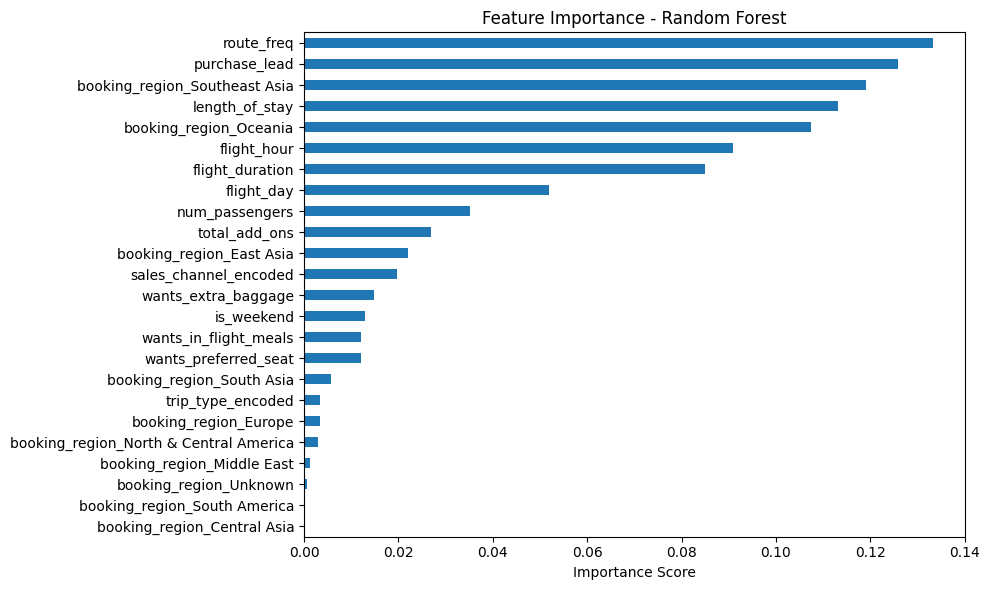

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importances
feature_importance = pd.Series(rf.feature_importances_, index=x.columns)
feature_importance = feature_importance.sort_values(ascending=True)

# Plot
plt.figure(figsize=(10, 6))
feature_importance.plot(kind='barh')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()